[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Maxencegu/python-datascience/blob/main/assignments/td08_pandas_agregation_et_transformation/td08_correction.ipynb)

⚠️ ***Gestion du temps : Le quiz de fin de séance est obligatoire et se ferme à la fin du TD. N'hésitez pas à sauter des exercices pour vous laisser 10 minutes. Tout le notebook doit être terminé avant le prochain TD.***

---

# **Introduction**

Au TD précédent, vous avez découvert les **DataFrames pandas** et appris à les explorer, les trier, les filtrer et à créer de nouvelles colonnes. Vous savez maintenant naviguer dans un jeu de données et en extraire les lignes et colonnes qui vous intéressent.

Mais explorer un tableau ligne par ligne ne suffit pas pour comprendre ce qu'il contient. Comment savoir si les ventes sont meilleures dans un type de magasin que dans un autre ? Quel département est le plus rentable ? Y a-t-il des tendances selon les saisons ?

Pour répondre à ces questions, il faut **résumer** et **agréger** les données — c'est-à-dire condenser des milliers de lignes en quelques chiffres significatifs.

La **statistique descriptive** fournit les outils pour cela : moyenne, médiane, écart-type, quantiles… Chaque indicateur raconte une histoire différente sur vos données, et choisir le bon indicateur selon la situation est une compétence fondamentale du data scientist.

Le **groupby** permet de calculer ces statistiques séparément pour chaque groupe — par type de magasin, par région, par période — en une seule ligne de code, sans répétition.

Les **tableaux croisés dynamiques** (pivot tables) offrent une présentation alternative, sous forme de tableau à double entrée, particulièrement lisible pour comparer deux variables simultanément — comme dans Excel, mais en Python.

Dans ce TD, vous apprendrez à :
- calculer des statistiques récapitulatives sur des colonnes numériques et des dates (`.mean()`, `.median()`, `.min()`, `.max()`, `.agg()`) ;
- comprendre et choisir le bon indicateur selon la distribution des données ;
- compter les valeurs d'une variable catégorielle avec `.value_counts()` ;
- supprimer les doublons pour éviter le double comptage avec `.drop_duplicates()` ;
- agréger des données par groupe avec `.groupby()` ;
- construire des tableaux croisés dynamiques avec `.pivot_table()`.

À l'issue de cette séance, vous serez capables de prendre un jeu de données réel, d'en extraire des statistiques par groupe et de produire un résumé structuré prêt à être interprété ou communiqué.

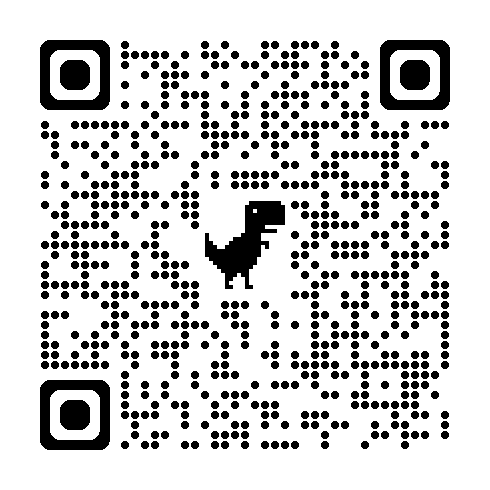

In [ ]:
# @title 📋 Feuille de présence (remplir maintenant)
from IPython.display import Image, display, HTML

display(HTML('<h3 style="font-family:sans-serif;">📋 Feuille de présence</h3>'))
display(Image("https://raw.githubusercontent.com/Maxencegu/python-datascience/main/assignments/td08_pandas_agregation_et_transformation/assets/qr_td08_presence.png", width=250))
display(HTML('<a href="https://forms.gle/X4S6x2ickHHd5Q9J9" target="_blank"><button style="font-size:15px;padding:8px 16px;margin-top:8px;cursor:pointer;">Ouvrir le formulaire</button></a>'))

In [1]:
# @title Configuration des ressources (ne pas modifier)
from IPython.display import Image, display, HTML

BASE_URL = "https://raw.githubusercontent.com/Maxencegu/python-datascience/main/assignments/td08_pandas_agregation_et_transformation/images/"

def afficher_infographie(nom_fichier, largeur=1300):
    display(Image(url=BASE_URL + nom_fichier, width=largeur))

In [ ]:
# @title Infographie — Workflow Complet du TD
afficher_infographie("13_workflow_complet_td_pro.png")

# **1. Transformer des DataFrames**

Maîtrisons les bases de pandas. Apprenez à inspecter des DataFrames et à réaliser des manipulations essentielles : trier des lignes, faire des sous-ensembles et ajouter de nouvelles colonnes.

## **1.1 Présentation des Dataframes**

In [ ]:
# @title Infographie — Introduction aux dataframes
afficher_infographie("01_introduction_dataframes_pro.png")

---
---

### **Exercice — Inspection d'un DataFrame**

Lorsque vous travaillez avec un nouveau DataFrame, la première chose à faire est de l'explorer pour comprendre ce qu'il contient.

Le DataFrame `homelessness` contient les estimations du nombre de sans-abri dans chacun des États américains en 2018 :
- `individual` — personnes sans domicile hors famille avec enfants
- `family_members` — personnes sans domicile en famille avec enfants
- `state_pop` — population totale de l'État

---

### **Instructions**

1. Affichez les premières lignes du DataFrame.
2. Affichez les informations sur les colonnes.
3. Affichez les dimensions du Dataframe.
4. Affichez les statistiques récapitulatives.

In [ ]:
import pandas as pd
import urllib.request

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/Maxencegu/python-datascience/main/datasets/homelessness.csv",
    "homelessness.csv"
)

homelessness = pd.read_csv("homelessness.csv", index_col=0)

# Print the head of the homelessness data
print(homelessness.head())
# Print information about homelessness
print(homelessness.info())
# Print the shape of homelessness
print(homelessness.shape)
# Print a description of homelessness
print(homelessness.describe())

               region       state  individuals  family_members  state_pop
0  East South Central     Alabama       2570.0           864.0    4887681
1             Pacific      Alaska       1434.0           582.0     735139
2            Mountain     Arizona       7259.0          2606.0    7158024
3  West South Central    Arkansas       2280.0           432.0    3009733
4             Pacific  California     109008.0         20964.0   39461588
<class 'pandas.core.frame.DataFrame'>
Index: 51 entries, 0 to 50
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   region          51 non-null     object 
 1   state           51 non-null     object 
 2   individuals     51 non-null     float64
 3   family_members  51 non-null     float64
 4   state_pop       51 non-null     int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 2.4+ KB
None
(51, 5)
         individuals  family_members     state_pop
count      51.0000

---

---

### **Exercice — Éléments d'un DataFrame**

Un DataFrame pandas se compose de trois éléments accessibles séparément :

- `.to_numpy()` — les valeurs sous forme de tableau NumPy 2D
- `.columns` — les noms des colonnes
- `.index` — les étiquettes des lignes

---

### **Instructions**

1. Affichez les valeurs de `homelessness` sous forme de tableau NumPy avec `.to_numpy()`.
2. Affichez les noms de colonnes avec `.columns`.
3. Affichez l'index des lignes avec `.index`.

In [ ]:
# Import pandas using the alias pd
import pandas as pd

# Print the values of homelessness as a NumPy array
print(homelessness.to_numpy())

# Print the column index of homelessness
print(homelessness.columns)

# Print the row index of homelessness
print(homelessness.index)

[['East South Central' 'Alabama' 2570.0 864.0 4887681]
 ['Pacific' 'Alaska' 1434.0 582.0 735139]
 ['Mountain' 'Arizona' 7259.0 2606.0 7158024]
 ['West South Central' 'Arkansas' 2280.0 432.0 3009733]
 ['Pacific' 'California' 109008.0 20964.0 39461588]
 ['Mountain' 'Colorado' 7607.0 3250.0 5691287]
 ['New England' 'Connecticut' 2280.0 1696.0 3571520]
 ['South Atlantic' 'Delaware' 708.0 374.0 965479]
 ['South Atlantic' 'District of Columbia' 3770.0 3134.0 701547]
 ['South Atlantic' 'Florida' 21443.0 9587.0 21244317]
 ['South Atlantic' 'Georgia' 6943.0 2556.0 10511131]
 ['Pacific' 'Hawaii' 4131.0 2399.0 1420593]
 ['Mountain' 'Idaho' 1297.0 715.0 1750536]
 ['East North Central' 'Illinois' 6752.0 3891.0 12723071]
 ['East North Central' 'Indiana' 3776.0 1482.0 6695497]
 ['West North Central' 'Iowa' 1711.0 1038.0 3148618]
 ['West North Central' 'Kansas' 1443.0 773.0 2911359]
 ['East South Central' 'Kentucky' 2735.0 953.0 4461153]
 ['West South Central' 'Louisiana' 2540.0 519.0 4659690]
 ['New 

## **1.2 Tri et sous ensemble**

In [ ]:
# @title Infographie — Tri et subdivision
afficher_infographie("02_tri_et_subdivision_pro.png")

---

---

### **Exercice — Tri des lignes**

En triant les lignes d'un DataFrame, vous faites remonter les données les plus intéressantes. Combinez `.sort_values()` avec `.head()` pour répondre à des questions comme *"Quels sont les États avec le plus de sans-abri ?"*.

| Trier sur…         | Syntaxe                            |
|--------------------|------------------------------------|
| une colonne        | `df.sort_values("col")`            |
| plusieurs colonnes | `df.sort_values(["col1", "col2"])` |

---

### **Instructions**

1. Triez `homelessness` par `individuals` (ordre croissant), enregistrez sous `homelessness_ind` et affichez les premières lignes.
2. Triez `homelessness` par `family_members` (ordre **décroissant**), enregistrez sous `homelessness_fam` et affichez les premières lignes.
3. Triez `homelessness` par `region` (croissant) puis par `family_members` (décroissant), enregistrez sous `homelessness_reg_fam` et affichez les premières lignes.

In [ ]:
# Sort homelessness by individuals
homelessness_ind = homelessness.sort_values('individuals')
# Print the top few rows
print(homelessness_ind.head())

# Sort homelessness by descending family members
homelessness_fam = homelessness.sort_values('family_members', ascending=False)
# Print the top few rows
print(homelessness_fam.head())

# Sort homelessness by region, then descending family members
homelessness_reg_fam = homelessness.sort_values(['region', 'family_members'], ascending=[True, False])
# Print the top few rows
print(homelessness_reg_fam.head())

                region         state  individuals  family_members  state_pop
50            Mountain       Wyoming        434.0           205.0     577601
34  West North Central  North Dakota        467.0            75.0     758080
7       South Atlantic      Delaware        708.0           374.0     965479
39         New England  Rhode Island        747.0           354.0    1058287
45         New England       Vermont        780.0           511.0     624358
                region          state  individuals  family_members  state_pop
32        Mid-Atlantic       New York      39827.0         52070.0   19530351
4              Pacific     California     109008.0         20964.0   39461588
21         New England  Massachusetts       6811.0         13257.0    6882635
9       South Atlantic        Florida      21443.0          9587.0   21244317
43  West South Central          Texas      19199.0          6111.0   28628666
                region      state  individuals  family_members  state_

---

---

### **Exercice — Création de sous-ensembles de colonnes**

Les crochets `[]` permettent de sélectionner uniquement les colonnes qui vous intéressent.

| Sélection          | Syntaxe                  | Résultat  |
|--------------------|--------------------------|-----------|
| Une colonne        | `df["col_a"]`            | Series    |
| Plusieurs colonnes | `df[["col_a", "col_b"]]` | DataFrame |

---

### **Instructions**

1. Créez une Series `individuals` contenant uniquement la colonne `individuals`.
2. Créez un DataFrame `state_fam` avec les colonnes `state` et `family_members`, dans cet ordre.
3. Créez un DataFrame `ind_state` avec les colonnes `individuals` et `state`, dans cet ordre.

In [ ]:
# Select the individuals column
individuals = homelessness['individuals']
print(individuals.head())

# Select the state and family_members columns
state_fam = homelessness[['state', 'family_members']]
print(state_fam.head())

# Select only the individuals and state columns, in that order
ind_state = homelessness[['individuals', 'state']]
print(ind_state.head())

0      2570.0
1      1434.0
2      7259.0
3      2280.0
4    109008.0
Name: individuals, dtype: float64
        state  family_members
0     Alabama           864.0
1      Alaska           582.0
2     Arizona          2606.0
3    Arkansas           432.0
4  California         20964.0
   individuals       state
0       2570.0     Alabama
1       1434.0      Alaska
2       7259.0     Arizona
3       2280.0    Arkansas
4     109008.0  California


---

---

### **Exercice — Création de sous-ensembles de lignes**

Pour filtrer les lignes d'un DataFrame, construisez une condition logique et passez-la entre crochets. Chaque ligne renvoie `True` ou `False` selon qu'elle satisfait la condition.

| Condition            | Syntaxe                     |
|----------------------|-----------------------------|
| Valeur numérique     | `df[df["col"] > 60]`        |
| Valeur textuelle     | `df[df["col"] == "valeur"]` |
| Plusieurs conditions | `df[(cond1) & (cond2)]`     |

> 💡 Avec plusieurs conditions, chaque condition doit être entre **parenthèses** et séparée par `&`.

---

### **Instructions**

1. Filtrez `homelessness` pour les États avec plus de 10 000 sans-abri (`individuals > 10000`), enregistrez sous `ind_gt_10k` et affichez le résultat.
2. Filtrez `homelessness` pour la région `"Mountain"`, enregistrez sous `mountain_reg` et affichez le résultat.
3. Filtrez `homelessness` pour les États de la région `"Pacific"` ayant moins de 1 000 membres de famille (`family_members < 1000`), enregistrez sous `fam_lt_1k_pac` et affichez le résultat.

In [ ]:
# Filter for rows where individuals is greater than 10000
ind_gt_10k = homelessness[homelessness['individuals'] > 10000]
# See the result
print(ind_gt_10k)

# Filter for rows where region is Mountain
mountain_reg = homelessness[homelessness['region'] == 'Mountain']
# See the result
print(mountain_reg)

# Filter for rows where family_members is less than 1000
# and region is Pacific
fam_lt_1k_pac = homelessness[(homelessness['family_members'] < 1000) & (homelessness['region'] == 'Pacific')]
# See the result
print(fam_lt_1k_pac)

                region       state  individuals  family_members  state_pop
4              Pacific  California     109008.0         20964.0   39461588
9       South Atlantic     Florida      21443.0          9587.0   21244317
32        Mid-Atlantic    New York      39827.0         52070.0   19530351
37             Pacific      Oregon      11139.0          3337.0    4181886
43  West South Central       Texas      19199.0          6111.0   28628666
47             Pacific  Washington      16424.0          5880.0    7523869
      region       state  individuals  family_members  state_pop
2   Mountain     Arizona       7259.0          2606.0    7158024
5   Mountain    Colorado       7607.0          3250.0    5691287
12  Mountain       Idaho       1297.0           715.0    1750536
26  Mountain     Montana        983.0           422.0    1060665
28  Mountain      Nevada       7058.0           486.0    3027341
31  Mountain  New Mexico       1949.0           602.0    2092741
44  Mountain        

---

---

### **Exercice — Sous-ensemble par variables catégorielles**

Quand vous voulez filtrer sur plusieurs valeurs d'une même colonne, `.isin()` est plus lisible qu'une série de conditions `==` combinées avec `|`.

```python
colors = ["brown", "black", "tan"]
df[df["color"].isin(colors)]
```

---
### **Instructions**

Filtrez homelessness pour les États du désert Mojave (Californie, Arizona, Nevada, Utah), enregistrez sous mojave_homelessness et affichez le résultat.

In [ ]:
# The Mojave Desert states
canu = ["California", "Arizona", "Nevada", "Utah"]

# Filter for rows in the Mojave Desert states
mojave_homelessness = homelessness[homelessness['state'].isin(canu)]

# See the result
print(mojave_homelessness)

      region       state  individuals  family_members  state_pop
2   Mountain     Arizona       7259.0          2606.0    7158024
4    Pacific  California     109008.0         20964.0   39461588
28  Mountain      Nevada       7058.0           486.0    3027341
44  Mountain        Utah       1904.0           972.0    3153550


## **1.3 Nouvelles colonnes**

In [ ]:
# @title Infographie — Nouvelles colonnes
afficher_infographie("03_nouvelles_colonnes_pro.png")

---

---

### **Exercice — Ajout de nouvelles colonnes**

Vous pouvez enrichir un DataFrame en créant des colonnes calculées à partir de colonnes existantes.

```python
df["nouvelle_col"] = df["col_a"] + df["col_b"]   # somme
df["proportion"]   = df["col_a"] / df["col_b"]   # ratio
```
---
### **Instructions**

1. Ajoutez une colonne total contenant la somme de individuals et family_members.
2. Ajoutez une colonne p_homeless contenant la proportion de sans-abri par rapport à la population totale (state_pop).

In [ ]:
# Add total col as sum of individuals and family_members
homelessness['total'] = homelessness['individuals'] + homelessness['family_members']

# Add p_homeless col as proportion of total homeless population to the state population
homelessness['p_homeless'] = homelessness['total'] / homelessness['state_pop']

# See the result
print(homelessness)

                region                 state  individuals  family_members  \
0   East South Central               Alabama       2570.0           864.0   
1              Pacific                Alaska       1434.0           582.0   
2             Mountain               Arizona       7259.0          2606.0   
3   West South Central              Arkansas       2280.0           432.0   
4              Pacific            California     109008.0         20964.0   
5             Mountain              Colorado       7607.0          3250.0   
6          New England           Connecticut       2280.0          1696.0   
7       South Atlantic              Delaware        708.0           374.0   
8       South Atlantic  District of Columbia       3770.0          3134.0   
9       South Atlantic               Florida      21443.0          9587.0   
10      South Atlantic               Georgia       6943.0          2556.0   
11             Pacific                Hawaii       4131.0          2399.0   

---

---

### **Exercice — Attaque combinée !**

Combinez les quatre opérations apprises pour répondre à une question réelle :

> **Quel État a le plus grand nombre de sans-abri pour 10 000 habitants ?**

---

### **Instructions**

1. Ajoutez une colonne `indiv_per_10k` : nombre de sans-abri (`individuals`) pour 10 000 personnes dans chaque État (`state_pop`).
2. Filtrez les lignes où `indiv_per_10k > 20`, enregistrez sous `high_homelessness`.
3. Triez `high_homelessness` par `indiv_per_10k` décroissant, enregistrez sous `high_homelessness_srt`.
4. Sélectionnez uniquement les colonnes `state` et `indiv_per_10k`, enregistrez sous `result` et affichez.

In [ ]:
# Create indiv_per_10k col as homeless individuals per 10k state pop
homelessness["indiv_per_10k"] = 10000 * homelessness["individuals"] / homelessness["state_pop"]

# Subset rows for indiv_per_10k greater than 20
high_homelessness = homelessness[homelessness["indiv_per_10k"] > 20]
print(high_homelessness)

# Sort high_homelessness by descending indiv_per_10k
high_homelessness_srt = high_homelessness.sort_values('indiv_per_10k', ascending=False)

# From high_homelessness_srt, select the state and indiv_per_10k cols
result = high_homelessness_srt[['state', 'indiv_per_10k']]

# See the result
print(result)

            region                 state  individuals  family_members  \
4          Pacific            California     109008.0         20964.0   
8   South Atlantic  District of Columbia       3770.0          3134.0   
11         Pacific                Hawaii       4131.0          2399.0   
28        Mountain                Nevada       7058.0           486.0   
32    Mid-Atlantic              New York      39827.0         52070.0   
37         Pacific                Oregon      11139.0          3337.0   
47         Pacific            Washington      16424.0          5880.0   

    state_pop     total  p_homeless  indiv_per_10k  
4    39461588  129972.0    0.003294      27.623825  
8      701547    6904.0    0.009841      53.738381  
11    1420593    6530.0    0.004597      29.079406  
28    3027341    7544.0    0.002492      23.314189  
32   19530351   91897.0    0.004705      20.392363  
37    4181886   14476.0    0.003462      26.636307  
47    7523869   22304.0    0.002964      21.

# **2. Agrégation de DataFrames**  

Dans ce chapitre, vous calculerez des statistiques récapitulatives sur les colonnes d'un DataFrame et vous apprendrez à maîtriser les statistiques groupées et les tableaux croisés dynamiques (pivot tables).

## **2.1 Statistiques récapitulatives"**

In [2]:
# @title Infographie — Statistiques récapitulatives
afficher_infographie("04_statistiques_recapitulatives_pro.png")

In [3]:
# @title Infographie — Concepts statistiques
afficher_infographie("04b_concepts_statistiques_pro.png")

---

---

### **Exercice — Moyenne et médiane**

Les statistiques récapitulatives condensent un grand nombre de valeurs en un seul chiffre représentatif. Le choix entre moyenne et médiane dépend de la distribution des données.

| Méthode     | Calcul                           | Sensible aux extrêmes ? |
|-------------|----------------------------------|:-----------------------:|
| `.mean()`   | Somme ÷ nombre de valeurs        | ✅ Oui                 |
| `.median()` | Valeur centrale (données triées) | ❌ Non                 |

---

### **Instructions**

1. Affichez les premières lignes de `sales`.
2. Affichez les informations sur les colonnes de `sales`.
3. Affichez la **moyenne** de la colonne `weekly_sales`.
4. Affichez la **médiane** de la colonne `weekly_sales`.

In [3]:
import pandas as pd
import urllib.request

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/Maxencegu/python-datascience/main/datasets/sales_subset.csv",
    "sales_subset.csv"
)

sales = pd.read_csv("sales_subset.csv", index_col=0)

# Print the head of the sales DataFrame
print(sales.head())

# Print the info about the sales DataFrame
print(sales.info())

# Print the mean of weekly_sales
print(sales['weekly_sales'].mean())

# Print the median of weekly_sales
print(sales['weekly_sales'].median())

   store type  department        date  weekly_sales  is_holiday  \
0      1    A           1  2010-02-05      24924.50       False   
1      1    A           1  2010-03-05      21827.90       False   
2      1    A           1  2010-04-02      57258.43       False   
3      1    A           1  2010-05-07      17413.94       False   
4      1    A           1  2010-06-04      17558.09       False   

   temperature_c  fuel_price_usd_per_l  unemployment  
0       5.727778              0.679451         8.106  
1       8.055556              0.693452         8.106  
2      16.816667              0.718284         7.808  
3      22.527778              0.748928         7.808  
4      27.050000              0.714586         7.808  
<class 'pandas.core.frame.DataFrame'>
Index: 10774 entries, 0 to 10773
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   store                 10774 non-null  int64  
 1   type  

---

---

### **Exercice — Récapitulatif des dates**

Les colonnes de type `datetime64` supportent elles aussi les statistiques récapitulatives. Les plus utiles sont `.min()` et `.max()`, qui permettent de connaître la **plage temporelle** couverte par le jeu de données.

---

### **Instructions**

1. Affichez la date **la plus récente** de la colonne `date`.
2. Affichez la date **la plus ancienne** de la colonne `date`.

In [4]:
# Print the maximum of the date column
print(sales['date'].max())

# Print the minimum of the date column
print(sales['date'].min())

2012-10-26
2010-02-05


---

---

### **Exercice — Agrégations avec .agg()**

La méthode `.agg()` permet d'appliquer des fonctions personnalisées à une ou plusieurs colonnes en une seule opération.

L'**intervalle interquartile (IQR)** est une alternative robuste à l'écart-type : il mesure l'étendue des 50 % de données centrales (Q3 − Q1), et est insensible aux valeurs extrêmes.

```python
df["col"].agg(ma_fonction)                     # une colonne, une fonction
df[["col1", "col2"]].agg(ma_fonction)          # plusieurs colonnes
df["col"].agg([ma_fonction, "median"])         # plusieurs fonctions
```
---

### **Instructions**

1. Appliquez la fonction iqr avec .agg() sur la colonne temperature_c.
2. Appliquez iqr sur les colonnes temperature_c, fuel_price_usd_per_l et unemployment, dans cet ordre.
3. Appliquez iqr et "median" sur ces mêmes trois colonnes.

In [5]:
# A custom IQR function
def iqr(column):
    return column.quantile(0.75) - column.quantile(0.25)

# Print IQR of the temperature_c column
print(sales['temperature_c'].agg(iqr))

# Update to print IQR of temperature_c, fuel_price_usd_per_l, & unemployment
print(sales[["temperature_c", "fuel_price_usd_per_l", "unemployment"]].agg(iqr))

# Update to print IQR and median of temperature_c, fuel_price_usd_per_l, & unemployment
print(sales[["temperature_c", "fuel_price_usd_per_l", "unemployment"]].agg([iqr, "median"]))

16.583333333333336
temperature_c           16.583333
fuel_price_usd_per_l     0.073176
unemployment             0.565000
dtype: float64
        temperature_c  fuel_price_usd_per_l  unemployment
iqr         16.583333              0.073176         0.565
median      16.966667              0.743381         8.099


---

---

### **Exercice — Statistiques cumulatives**

Les statistiques cumulatives permettent de suivre l'évolution d'un indicateur dans le temps. À chaque ligne, la valeur cumulée intègre toutes les lignes précédentes.

| Méthode     | Résultat                                     |
|-------------|----------------------------------------------|
| `.cumsum()` | Total accumulé jusqu'à cette date            |
| `.cummax()` | Meilleure valeur observée jusqu'à cette date |

> 💡 **Important :** triez toujours les données par date avant de calculer des statistiques cumulatives, sinon l'ordre des lignes fausse le résultat.

---

### **Instructions**

1. Triez `sales_1_1` par `date` (ordre croissant).
2. Ajoutez une colonne `cum_weekly_sales` contenant la somme cumulée de `weekly_sales`.
3. Ajoutez une colonne `cum_max_sales` contenant le maximum cumulatif de `weekly_sales`.
4. Affichez les colonnes `date`, `weekly_sales`, `cum_weekly_sales` et `cum_max_sales`.

In [6]:
# Créer sales_1_1 : magasin 1, rayon 1
sales_1_1 = sales[(sales["store"] == 1) & (sales["department"] == 1)]

# Sort sales_1_1 by date
sales_1_1 = sales_1_1.sort_values('date')

# Get the cumulative sum of weekly_sales, add as cum_weekly_sales col
sales_1_1["cum_weekly_sales"] = sales_1_1["weekly_sales"].cumsum()

# Get the cumulative max of weekly_sales, add as cum_max_sales col
sales_1_1["cum_max_sales"] = sales_1_1["weekly_sales"].cummax()

# See the columns you calculated
print(sales_1_1[["date", "weekly_sales", "cum_weekly_sales", "cum_max_sales"]])

          date  weekly_sales  cum_weekly_sales  cum_max_sales
0   2010-02-05      24924.50          24924.50       24924.50
1   2010-03-05      21827.90          46752.40       24924.50
2   2010-04-02      57258.43         104010.83       57258.43
3   2010-05-07      17413.94         121424.77       57258.43
4   2010-06-04      17558.09         138982.86       57258.43
5   2010-07-02      16333.14         155316.00       57258.43
6   2010-08-06      17508.41         172824.41       57258.43
7   2010-09-03      16241.78         189066.19       57258.43
8   2010-10-01      20094.19         209160.38       57258.43
9   2010-11-05      34238.88         243399.26       57258.43
10  2010-12-03      22517.56         265916.82       57258.43
11  2011-01-07      15984.24         281901.06       57258.43


## **2.2 Comptage**

In [12]:
# @title Infographie — Comptage
afficher_infographie("05_comptage_pro.png")

---

---

### **Exercice — Suppression des doublons**

Avant de compter, il faut s'assurer de ne pas compter plusieurs fois la même chose. `.drop_duplicates()` garde une seule ligne par combinaison de valeurs uniques.

```python
df.drop_duplicates(subset=["col1", "col2"])
```
---
### **Instructions**

1. Supprimez les doublons sur les paires store / type, enregistrez sous store_types et affichez les premières lignes.
2. Supprimez les doublons sur les paires store / department, enregistrez sous store_depts et affichez les premières lignes.
3. Filtrez les semaines de vacances (is_holiday == True), supprimez les doublons sur date, enregistrez sous holiday_dates.
4. Affichez la colonne date de holiday_dates.

In [7]:
# import pandas
import pandas as pd

# Drop duplicate store/type combinations
store_types = sales.drop_duplicates(subset=["store","type"])
print(store_types.head())

# Drop duplicate store/department combinations
store_depts = sales.drop_duplicates(subset=["store","department"])
print(store_depts.head())

# Subset the rows where is_holiday is True and drop duplicate dates
holiday_dates = sales[sales["is_holiday"]].drop_duplicates("date")

# Print date col of holiday_dates
print(holiday_dates["date"])

      store type  department        date  weekly_sales  is_holiday  \
0         1    A           1  2010-02-05      24924.50       False   
901       2    A           1  2010-02-05      35034.06       False   
1798      4    A           1  2010-02-05      38724.42       False   
2699      6    A           1  2010-02-05      25619.00       False   
3593     10    B           1  2010-02-05      40212.84       False   

      temperature_c  fuel_price_usd_per_l  unemployment  
0          5.727778              0.679451         8.106  
901        4.550000              0.679451         8.324  
1798       6.533333              0.686319         8.623  
2699       4.683333              0.679451         7.259  
3593      12.411111              0.782478         9.765  
    store type  department        date  weekly_sales  is_holiday  \
0       1    A           1  2010-02-05      24924.50       False   
12      1    A           2  2010-02-05      50605.27       False   
24      1    A           3 

---

---

### **Exercice — Comptage des variables catégorielles**

`.value_counts()` compte le nombre d'occurrences de chaque valeur dans une colonne catégorielle.

| Argument         | Effet                                            |
|------------------|--------------------------------------------------|
| `sort=True`      | Valeurs les plus fréquentes en tête (défaut)     |
| `normalize=True` | Proportions (somme = 1) à la place des effectifs |

---

### **Instructions**

1. Comptez le nombre de magasins par `type` dans `store_types`.
2. Comptez la **proportion** de magasins par `type` dans `store_types`.
3. Comptez le nombre de magasins par `department` dans `store_depts`, ordre décroissant.
4. Comptez la **proportion** de magasins par `department` dans `store_depts`, ordre décroissant.

In [8]:
# Count the number of stores of each type
store_counts = store_types['type'].value_counts()
print(store_counts)

# Get the proportion of stores of each type
store_props = store_types['type'].value_counts(normalize=True)
print(store_props)

# Count the number of stores for each department and sort
dept_counts_sorted = store_depts['department'].value_counts(sort=True)
print(dept_counts_sorted)

# Get the proportion of stores in each department and sort
dept_props_sorted = store_depts['department'].value_counts(sort=True, normalize=True)
print(dept_props_sorted)

type
A    11
B     1
Name: count, dtype: int64
type
A    0.916667
B    0.083333
Name: proportion, dtype: float64
department
1     12
2     12
3     12
4     12
5     12
      ..
37    10
48     8
50     6
39     4
43     2
Name: count, Length: 80, dtype: int64
department
1     0.012917
2     0.012917
3     0.012917
4     0.012917
5     0.012917
        ...   
37    0.010764
48    0.008611
50    0.006459
39    0.004306
43    0.002153
Name: proportion, Length: 80, dtype: float64


## **2.3 Statistiques récapitulatives groupées**

In [2]:
# @title Infographie — Group By
afficher_infographie("06_groupby_pro.png")

---

---

### **Exercice — Proportion des ventes par type de magasin**

Walmart distingue trois types de magasins :
- **Type A** — Hypermarchés (*supercenters*)
- **Type B** — Magasins discount (*discount stores*)
- **Type C** — Supérettes de proximité (*neighborhood markets*)

Dans cet exercice, vous calculerez manuellement la proportion des ventes réalisées dans chaque type — **sans `.groupby()`** — pour bien comprendre ce que `.groupby()` automatise ensuite.

---

### **Instructions**

1. Calculez le total de `weekly_sales` pour l'ensemble du dataset, enregistrez sous `sales_all`.
2. Calculez les ventes totales pour les magasins de type `"A"`, enregistrez sous `sales_A`.
3. Faites de même pour le type `"B"` → `sales_B` et le type `"C"` → `sales_C`.
4. Calculez la proportion des ventes pour chaque type en divisant par `sales_all`, et affichez le résultat.

In [15]:
# Calc total weekly sales
sales_all = sales["weekly_sales"].sum()

# Subset for type A stores, calc total weekly sales
sales_A = sales[sales["type"] == "A"]["weekly_sales"].sum()

# Subset for type B stores, calc total weekly sales
sales_B = sales[sales["type"] == "B"]["weekly_sales"].sum()

# Subset for type C stores, calc total weekly sales
sales_C = sales[sales["type"] == "C"]["weekly_sales"].sum()

# Get proportion for each type
sales_propn_by_type = [sales_A, sales_B, sales_C] / sales_all
print(sales_propn_by_type)

[0.9097747 0.0902253 0.       ]


---

---

### **Exercice — Calculs avec .groupby()**

`.groupby()` automatise ce que vous avez fait manuellement dans l'exercice précédent — en une seule ligne au lieu de plusieurs filtres répétés.

---

### **Instructions**

1. Groupez `sales` par `"type"`, calculez la somme de `"weekly_sales"`, enregistrez sous `sales_by_type` et affichez.
2. Divisez `sales_by_type` par sa propre somme pour obtenir les proportions, enregistrez sous `sales_propn_by_type` et affichez.
3. Groupez `sales` par `"type"` **et** `"is_holiday"`, calculez la somme de `"weekly_sales"`, enregistrez sous `sales_by_type_is_holiday` et affichez.

In [18]:
# Group by type; calc total weekly sales
sales_by_type = sales.groupby("type")["weekly_sales"].sum()

# Get proportion for each type
sales_propn_by_type = sales_by_type / sum(sales["weekly_sales"])
print(sales_propn_by_type)

# Group by type and is_holiday; calc total weekly sales
sales_by_type_is_holiday = sales.groupby(["type", "is_holiday"])["weekly_sales"].sum()
print(sales_by_type_is_holiday)

type
A    0.909775
B    0.090225
Name: weekly_sales, dtype: float64
type  is_holiday
A     False         2.336927e+08
      True          2.360181e+04
B     False         2.317678e+07
      True          1.621410e+03
Name: weekly_sales, dtype: float64


---

---

### **Exercice — Plusieurs récapitulatifs groupés**

`.groupby()` et `.agg()` se combinent pour calculer plusieurs statistiques sur plusieurs colonnes en une seule opération.

```python
df.groupby("groupe")["colonne"].agg(["min", "max", "mean", "median"])
df.groupby("groupe")[["col1", "col2"]].agg(["min", "max", "mean", "median"])
```
---

### **Instructions**

1. Calculez le min, max, moyenne et médiane de weekly_sales par type de magasin, enregistrez sous sales_stats et affichez.
2. Calculez les mêmes statistiques pour unemployment et fuel_price_usd_per_l par type de magasin, enregistrez sous unemp_fuel_stats et affichez.

In [19]:
# For each store type, aggregate weekly_sales: get min, max, mean, and median
sales_stats = sales.groupby("type")["weekly_sales"].agg(["min","max","mean","median"])

# Print sales_stats
print(sales_stats)

# For each store type, aggregate unemployment and fuel_price_usd_per_l: get min, max, mean, and median
unemp_fuel_stats = sales.groupby("type")[["unemployment", "fuel_price_usd_per_l"]].agg(["min","max","mean","median"])

# Print unemp_fuel_stats
print(unemp_fuel_stats)

         min        max          mean    median
type                                           
A    -1098.0  293966.05  23674.667242  11943.92
B     -798.0  232558.51  25696.678370  13336.08
     unemployment                         fuel_price_usd_per_l            \
              min    max      mean median                  min       max   
type                                                                       
A           3.879  8.992  7.972611  8.067             0.664129  1.107410   
B           7.170  9.765  9.279323  9.199             0.760023  1.107674   

                          
          mean    median  
type                      
A     0.744619  0.735455  
B     0.805858  0.803348  


## **2.4 Les tableaux croisés dynamiques**

In [28]:
# @title Infographie — Les tables pivot
afficher_infographie("07_pivot_table_pro.png")

---

---

### **Exercice — Tri croisé sur une variable**

`.pivot_table()` est une alternative à `.groupby()` qui présente les résultats sous forme de tableau. Par défaut, `aggfunc="mean"`.

```python
df.pivot_table(values="col_valeur", index="col_groupe")
df.pivot_table(values="col_valeur", index="col_groupe", aggfunc=["mean", "median"])
df.pivot_table(values="col_valeur", index="col_groupe", columns="col_col")
```
---

### **Instructions**

1. Calculez la moyenne de weekly_sales par type avec .pivot_table(), enregistrez sous mean_sales_by_type et affichez.
2. Calculez la moyenne et la médiane de weekly_sales par type, enregistrez sous mean_med_sales_by_type et affichez.
3. Calculez la moyenne de weekly_sales par type et is_holiday, enregistrez sous mean_sales_by_type_holiday et affichez.

In [23]:
# Pivot for mean weekly_sales for each store type
mean_sales_by_type = sales.pivot_table(values="weekly_sales", index="type")
# Print mean_sales_by_type
print(mean_sales_by_type)
print("----------------")


# Pivot for mean and median weekly_sales for each store type
mean_med_sales_by_type = sales.pivot_table(values="weekly_sales", index="type", aggfunc=["mean", "median"])
# Print mean_med_sales_by_type
print(mean_med_sales_by_type)
print("----------------")

# Pivot for mean weekly_sales by store type and holiday
mean_sales_by_type_holiday = sales.pivot_table(values="weekly_sales", index="type", columns="is_holiday")
# Print mean_sales_by_type_holiday
print(mean_sales_by_type_holiday)

      weekly_sales
type              
A     23674.667242
B     25696.678370
----------------
              mean       median
      weekly_sales weekly_sales
type                           
A     23674.667242     11943.92
B     25696.678370     13336.08
----------------
is_holiday         False      True 
type                               
A           23768.583523  590.04525
B           25751.980533  810.70500


---

---

### **Exercice — fill_value et margins**

Deux arguments utiles de `.pivot_table()` pour compléter et enrichir un tableau croisé :

| Argument | Rôle |
|---|---|
| `fill_value=0` | Remplace les `NaN` par 0 (ou toute autre valeur) |
| `margins=True` | Ajoute une ligne et une colonne `"All"` avec la moyenne globale |

---

### **Instructions**

1. Calculez la moyenne de `weekly_sales` par `type` et `department`, remplacez les `NaN` par `0`, enregistrez sous `mean_sales_pivot` et affichez.
2. Faites de même en ajoutant `margins=True` pour obtenir les totaux par ligne et colonne, enregistrez sous `mean_sales_pivot_margins` et affichez.

In [27]:
# Print mean weekly_sales by department and type; fill missing values with 0
print(sales.pivot_table(values="weekly_sales", index="department", columns="type", fill_value=0))

# Print the mean weekly_sales by department and type; fill missing values with 0s; sum all rows and cols
print(sales.pivot_table(values="weekly_sales", index="department", columns="type", fill_value=0, margins=True))

type                    A              B
department                              
1            30961.725379   44050.626667
2            67600.158788  112958.526667
3            17160.002955   30580.655000
4            44285.399091   51219.654167
5            34821.011364   63236.875000
...                   ...            ...
95          123933.787121   77082.102500
96           21367.042857    9528.538333
97           28471.266970    5828.873333
98           12875.423182     217.428333
99             379.123659       0.000000

[80 rows x 2 columns]
type                   A              B           All
department                                           
1           30961.725379   44050.626667  32052.467153
2           67600.158788  112958.526667  71380.022778
3           17160.002955   30580.655000  18278.390625
4           44285.399091   51219.654167  44863.253681
5           34821.011364   63236.875000  37189.000000
...                  ...            ...           ...
96          

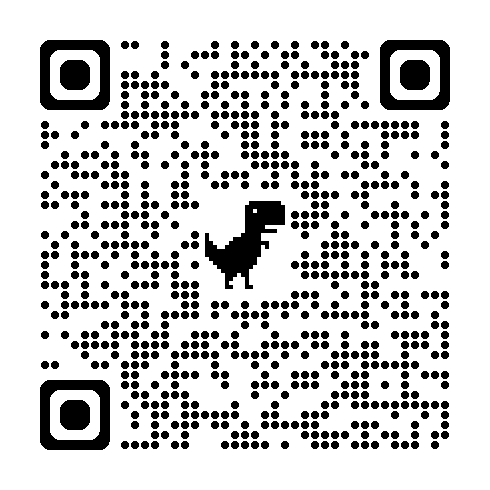

In [31]:
# @title 🧠 Quiz de fin de séance
from IPython.display import Image, display, HTML

display(HTML('<h3 style="font-family:sans-serif;">🧠 Quiz fin de séance</h3>'))
display(Image("https://raw.githubusercontent.com/Maxencegu/python-datascience/main/assignments/td08_pandas_agregation_et_transformation/assets/qr_td08_quiz.png", width=250))
display(HTML('<a href="https://forms.gle/xeZRaUPPd8B2atTQ7" target="_blank"><button style="font-size:15px;padding:8px 16px;margin-top:8px;cursor:pointer;">Ouvrir le quiz</button></a>'))